# TPV Lifting, step by step 🧭
### A beginner's guide to Tri-Perspective-View lifting with `Halos-lift`

**Goal of this notebook:** by the end you will understand, *and have run*, every piece that turns
a few flat camera photos into a 3D understanding of the world using **TPVFormer** (Huang et al., CVPR 2023).

Every cell runs on a CPU in seconds. No CUDA, no `mmcv`: the library is pure PyTorch, so you can
read and poke every line.

| Step | Question it answers |
|---|---|
| 1 | What is "lifting" and why TPV? |
| 2 | How do we describe 3D space? (`GridSpec`) |
| 3 | What *is* a TPV? (`TPVPlanes`) |
| 4 | Where does the data come from? (synthetic scenes + `Cameras`) |
| 5 | How does a 3D point find its pixel? (projection) |
| 6 | Which pixels should each plane cell look at? (reference points) |
| 7 | How does it "look" at pixels? (deformable attention) |
| 8 | How do the planes talk to each other? (cross-view hybrid attention) |
| 9 | One full encoder layer |
| 10 | The whole lifter: images → planes |
| 11 | Planes → voxels and arbitrary 3D points (the aggregator) |
| 12 | Train it and see it learn |
| 13 | Prove it really uses geometry |
| 14 | Exercises |

In [1]:
import math, time
import numpy as np
import torch, torch.nn.functional as F
import matplotlib.pyplot as plt

from lifting import GridSpec, Cameras, build_tpvformer
from lifting.data import SceneBatch, SyntheticSceneDataset
from lifting.lifters.tpvformer import TPVPlanes, TPVReferencePoints, TPVFormerLifter, TPVFormerLayer, TPVAggregator
from lifting.attention import CrossViewHybridAttention, SpatialCrossAttention
from lifting.ops import multi_scale_deformable_attn_2d
from lifting.training import OccupancyTask, Trainer

torch.manual_seed(0)
plt.rcParams.update({"figure.dpi": 110, "image.interpolation": "nearest"})
print("torch", torch.__version__)

torch 2.14.1


## Step 1: What is "lifting", and why *Tri-Perspective View*?

A self-driving car or robot sees the world through **2D photos**, but it must act in **3D**.
*Lifting* means: take 2D image features and produce a 3D (or bird's-eye) feature representation.

Three ways to hold 3D space in memory, for a region of `X × Y × Z` cells:

| representation | memory | problem |
|---|---|---|
| **Voxels** (full 3D grid) | `X·Y·Z` | very expensive: 200×200×16 = **640,000** cells |
| **BEV** (bird's-eye, top-down only) | `X·Y` | cheap, but **squashes height**: a person and the tree above them share one cell |
| **TPV** (three planes) | `X·Y + X·Z + Y·Z` | cheap *and* keeps height |

**TPV idea:** a 3D scene casts three "shadows": onto the ground (**top view**, `xy`), onto a side wall
(`xz`) and onto a front wall (`yz`). To know what is at 3D point `(x, y, z)`, look up its location in all three
shadows and **add** the features. Like finding a fly in a room by seeing it on three walls.

### 🖼️ Diagram: three shadows of one 3D point
Left: a single 3D point (red) is projected onto the **floor** (xy), the **back wall** (xz) and the **side wall** (yz). Right: its feature is simply the sum of the three 2D lookups, then a small MLP classifies it.

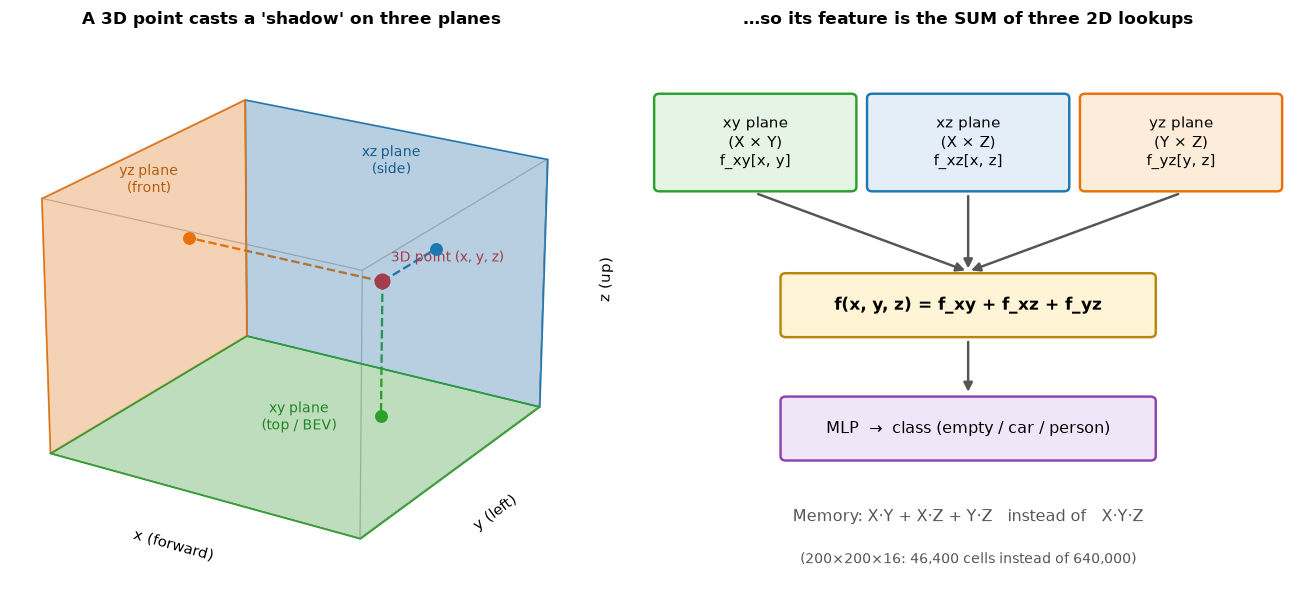

In [2]:
import os, sys
for _p in (".", "notebooks", os.path.join("..", "notebooks")):          # find lifting_diagrams.py next to the notebooks
    if os.path.exists(os.path.join(_p, "lifting_diagrams.py")):
        sys.path.insert(0, _p); break
import lifting_diagrams as dg
dg.fig_tpv_shadows()

In [3]:
# How much cheaper is TPV than voxels at a realistic size?
X, Y, Z = 200, 200, 16
voxels = X * Y * Z
tpv = X * Y + X * Z + Y * Z
bev = X * Y
print(f"voxels : {voxels:>9,} cells")
print(f"BEV    : {bev:>9,} cells  (no height)")
print(f"TPV    : {tpv:>9,} cells  ({voxels / tpv:.1f}x fewer than voxels, keeps height)")

voxels :   640,000 cells
BEV    :    40,000 cells  (no height)
TPV    :    46,400 cells  (13.8x fewer than voxels, keeps height)


## Step 2: Describing 3D space with `GridSpec`

Everything lives in the **ego frame** (the vehicle/robot): `x` forward, `y` left, `z` up, in metres.
A `GridSpec` says *which box of the world we care about* and *how finely we chop it up*.

This tiny dataclass is used by every module, so spend a minute here.

In [4]:
grid = GridSpec(x_bounds=(-16, 16), y_bounds=(-16, 16), z_bounds=(-1, 3), resolution=(32, 32, 4))

print("extent (m)       :", grid.extents)
print("voxel size (m)   :", grid.voxel_size, " <- 1m x 1m x 1m cells")
print("resolution X,Y,Z :", grid.resolution)

centers = grid.voxel_centers()
print("voxel_centers    :", tuple(centers.shape), " = (X, Y, Z, 3) metric xyz of every voxel centre")
print("first voxel      :", centers[0, 0, 0].tolist(), "(metres)")
print("last voxel       :", centers[-1, -1, -1].tolist())

extent (m)       : (32, 32, 4)
voxel size (m)   : (1.0, 1.0, 1.0)  <- 1m x 1m x 1m cells
resolution X,Y,Z : (32, 32, 4)
voxel_centers    : (32, 32, 4, 3)  = (X, Y, Z, 3) metric xyz of every voxel centre
first voxel      : [-15.5, -15.5, -0.5] (metres)
last voxel       : [15.5, 15.5, 2.5]


Two coordinate systems you will see everywhere:

* **metric** `(x, y, z)` in metres, e.g. `(5.0, -2.0, 0.5)`
* **cell index / normalised** coordinates: `to_index` gives continuous cell numbers, `to_normalized` maps the box to `[-1, 1]`
  (what `F.grid_sample` wants).

In [5]:
p = torch.tensor([[5.0, -2.0, 0.5]])           # a point 5 m ahead, 2 m to the right, 0.5 m up
print("cell index  :", grid.to_index(p).tolist())       # which cell it is in (continuous)
print("normalised  :", grid.to_normalized(p).tolist())  # in [-1, 1]
print("inside grid?:", grid.contains(p).tolist())
print("far away    :", grid.contains(torch.tensor([[100.0, 0, 0]])).tolist())

cell index  : [[21.0, 14.0, 1.5]]
normalised  : [[0.3125, -0.125, -0.25]]
inside grid?: [True]
far away    : [False]


## Step 3: What *is* a TPV? `TPVPlanes`

Three feature maps (each has `C` channels):

| plane | shape | looks at |
|---|---|---|
| `xy` | `(B, C, X, Y)` | scene from the **top** (this is a BEV map!) |
| `xz` | `(B, C, X, Z)` | scene from the **side** |
| `yz` | `(B, C, Y, Z)` | scene from the **front** |

The key formula of the whole method:

$$ f(x, y, z) = f_{xy}(x, y) + f_{xz}(x, z) + f_{yz}(y, z) $$

Let's build planes with just **1 channel and tiny numbers** so you can verify it by hand.

In [6]:
B, C, nx, ny, nz = 1, 1, 3, 4, 2
xy = torch.arange(nx * ny, dtype=torch.float32).view(B, C, nx, ny)          # 0..11
xz = 100 + torch.arange(nx * nz, dtype=torch.float32).view(B, C, nx, nz)    # 100..105
yz = 1000 + torch.arange(ny * nz, dtype=torch.float32).view(B, C, ny, nz)   # 1000..1007
toy = TPVPlanes(xy, xz, yz)

print("resolution:", toy.resolution)
vox = toy.to_voxels()
print("voxel volume shape:", tuple(vox.shape), "= (B, C, X, Y, Z)")

i, j, k = 2, 1, 1
by_hand = xy[0, 0, i, j] + xz[0, 0, i, k] + yz[0, 0, j, k]
print(f"\nvoxel({i},{j},{k}) = xy[{i},{j}] + xz[{i},{k}] + yz[{j},{k}]")
print(f"             = {xy[0,0,i,j]:.0f} + {xz[0,0,i,k]:.0f} + {yz[0,0,j,k]:.0f} = {by_hand:.0f}")
print("library says  :", vox[0, 0, i, j, k].item())
assert torch.equal(vox[0, 0, i, j, k], by_hand)

resolution: (3, 4, 2)
voxel volume shape: (1, 1, 3, 4, 2) = (B, C, X, Y, Z)

voxel(2,1,1) = xy[2,1] + xz[2,1] + yz[1,1]
             = 9 + 105 + 1003 = 1117
library says  : 1117.0


**Under the hood:** `to_voxels` is just three broadcasts:
`xy[..., None] + xz[:, :, :, None, :] + yz[:, :, None, :, :]`. Each plane is stretched along the axis it's missing, then they're added.

### Asking about *any* point, not just voxel centres
`sample_points` takes metric-normalised coordinates and bilinearly interpolates each plane (`F.grid_sample`).
At a voxel's centre it must agree exactly with the voxel volume. Let's check with random 8-channel planes.

In [7]:
grid_s = GridSpec(resolution=(8, 8, 4))
planes = TPVPlanes(torch.randn(1, 8, 8, 8), torch.randn(1, 8, 8, 4), torch.randn(1, 8, 8, 4))

voxels = planes.to_voxels()                                   # (1, 8, X, Y, Z)
centers = grid_s.voxel_centers().reshape(1, -1, 3)            # (1, X*Y*Z, 3) in metres
via_points = planes.sample_points(grid_s.to_normalized(centers))   # (1, 8, X*Y*Z)

print("max |voxel - point-sample| =", (voxels.flatten(2) - via_points).abs().max().item())
assert torch.allclose(voxels.flatten(2), via_points, atol=1e-5)

# ...and between voxel centres we get smooth interpolation
off = centers[:, :1] + torch.tensor([[[0.3, 0.2, 0.1]]])
print("a point between voxels still works:", tuple(planes.sample_points(grid_s.to_normalized(off)).shape))

max |voxel - point-sample| = 0.0
a point between voxels still works: (1, 8, 1)


Planes can also be flattened into one long list of **tokens** (`XY + XZ + YZ` tokens, each a `C`-vector).
That is what the transformer layers will operate on.

In [8]:
tokens = planes.to_tokens()
print("tokens:", tuple(tokens.shape), "= (B, 64 + 32 + 32, C)")
back = TPVPlanes.from_tokens(tokens, (8, 8, 4))
assert torch.equal(back.xy, planes.xy) and torch.equal(back.xz, planes.xz) and torch.equal(back.yz, planes.yz)
print("round trip planes -> tokens -> planes is lossless ✓")

tokens: (1, 128, 8) = (B, 64 + 32 + 32, C)
round trip planes -> tokens -> planes is lossless ✓


## Step 4: The data: synthetic multi-camera scenes

Real datasets (nuScenes, Occ3D) are huge. This repo ships a **procedural world**: a checkerboard
ground, sky, and box-shaped *vehicles* (red) and *pedestrians* (blue), rendered by an exact ray caster from
4 cameras. The labels are exact too:

* `bev_labels (X, Y)`: top-down class map
* `occupancy (X, Y, Z)`: 3D class map; **this is the target of TPVFormer**
* `depth`: ground-truth depth (we don't need it for TPV)

Class ids: `0` = empty, `1` = vehicle, `2` = pedestrian.

In [9]:
grid = GridSpec(resolution=(32, 32, 4))
data = SyntheticSceneDataset(256, grid, seed=1)
sample = data[0]
for k, v in sample.items():
    print(f"{k:12s} {tuple(v.shape)}  {v.dtype}")

images       (4, 3, 48, 96)  torch.float32
depth        (4, 48, 96)  torch.float32
intrinsics   (4, 3, 3)  torch.float32
cam_to_ego   (4, 4, 4)  torch.float32
bev_labels   (32, 32)  torch.int64
occupancy    (32, 32, 4)  torch.int64


images    : (4, 4, 3, 48, 96)  = (B, N cameras, 3, H, W)
occupancy : (4, 32, 32, 4)  = (B, X, Y, Z)


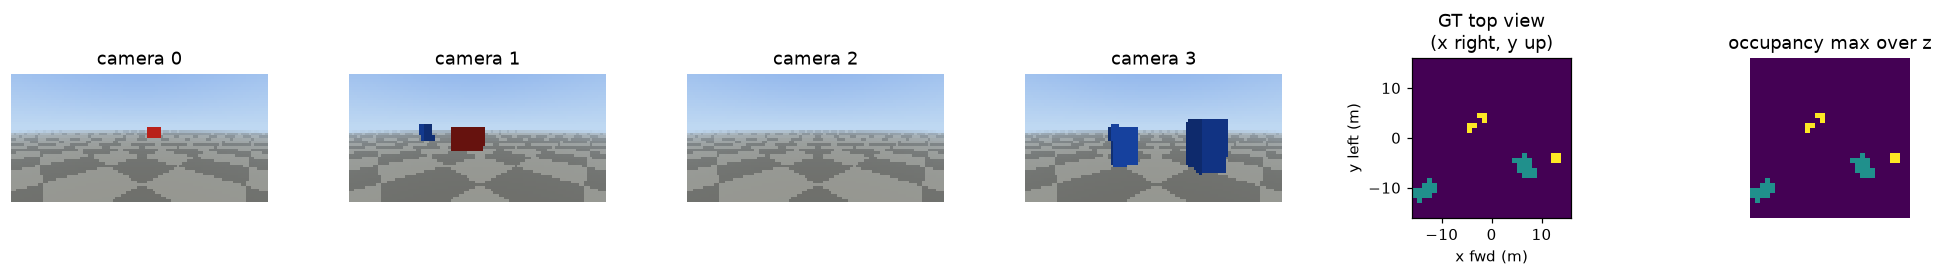

In [10]:
batch = SceneBatch.collate([data[i] for i in range(4)])
print("images    :", tuple(batch.images.shape), " = (B, N cameras, 3, H, W)")
print("occupancy :", tuple(batch.occupancy.shape), " = (B, X, Y, Z)")

fig, ax = plt.subplots(1, 6, figsize=(18, 2.6))
for n in range(4):
    ax[n].imshow(batch.images[0, n].permute(1, 2, 0)); ax[n].set_title(f"camera {n}"); ax[n].axis("off")
ax[4].imshow(batch.bev_labels[0].T, origin="lower", cmap="viridis", vmin=0, vmax=2,
             extent=[grid.x_bounds[0], grid.x_bounds[1], grid.y_bounds[0], grid.y_bounds[1]])
ax[4].set_title("GT top view\n(x right, y up)"); ax[4].set_xlabel("x fwd (m)"); ax[4].set_ylabel("y left (m)")
ax[5].imshow(batch.occupancy[0].amax(2).T, origin="lower", cmap="viridis", vmin=0, vmax=2)
ax[5].set_title("occupancy max over z"); ax[5].axis("off")
plt.tight_layout(); plt.show()

> 💡 **Look at the top-view panel**: the ego vehicle is at the centre `(0, 0)`. Yellow = pedestrians,
> teal = vehicles (viridis colours). The cameras are positioned around the origin, and the rig is **randomly rotated in each scene**.
> The network can only solve the task by *using the camera calibration*. We test that in Step 13.

## Step 5: Geometry. How does a 3D point find its pixel?

`Cameras` bundles, for each of `N` cameras:

* `intrinsics (B,N,3,3)`: focal length and principal point (pixel ← camera)
* `cam_to_ego (B,N,4,4)`: where the camera sits and points (ego ← camera)

`cameras.project(points)` does: **ego → camera frame → perspective divide → pixel `(u, v)`**.

$$ \begin{bmatrix}u\,d\\ v\,d\\ d\end{bmatrix} = K \,(R^{\top}(p - t)) $$
where `d` is the depth (distance along the optical axis).
Let's verify by hand for one camera, one point.

In [11]:
cams = batch.cameras
print("image_size (H, W):", cams.image_size)

# Make a point that camera 0 definitely sees: the centre pixel of camera 0, 8 m away.
centre = torch.tensor([[[48.0, 24.0]]]).expand(cams.batch_size, 1, 2)
depth0 = torch.full((cams.batch_size, 1, 1), 8.0)
P = cams.unproject(centre.unsqueeze(1).expand(-1, cams.num_cameras, -1, -1),
                   depth0.unsqueeze(1).expand(-1, cams.num_cameras, -1, -1).squeeze(-1))[:, 0]   # (B,1,3) via cam 0
print("3D point (ego frame, metres):", P[0, 0].tolist())

uv, depth, valid = cams.project(P)
print("uv    (B,N,P,2):", tuple(uv.shape))
for n in range(cams.num_cameras):
    print(f"cam {n}: pixel=({uv[0,n,0,0]:8.1f},{uv[0,n,0,1]:8.1f})  depth={depth[0,n,0]:6.2f} m  visible={bool(valid[0,n,0])}")

# --- by hand for camera 0 ---
K = cams.intrinsics[0, 0]; T = cams.cam_to_ego[0, 0]
R, t = T[:3, :3], T[:3, 3]
p_cam = R.T @ (P[0, 0] - t)                        # ego -> camera frame
pix = K @ p_cam                                    # camera frame -> homogeneous pixel
print("\nby hand, cam 0: pixel", (pix[:2] / pix[2]).tolist(), " depth", p_cam[2].item())

image_size (H, W): (48, 96)
3D point (ego frame, metres): [-5.470848560333252, -5.776723861694336, 0.7637723088264465]
uv    (B,N,P,2): (4, 4, 1, 2)
cam 0: pixel=(    48.0,    24.0)  depth=  8.00 m  visible=True
cam 1: pixel=(  3714.1,   407.2)  depth=  0.09 m  visible=False
cam 2: pixel=(-37560864.0,-12081221.0)  depth= -7.83 m  visible=False
cam 3: pixel=( -3618.1,   407.2)  depth=  0.09 m  visible=False

by hand, cam 0: pixel [48.0, 24.0]  depth 7.999999523162842


### The reverse trip, and why lifting is *hard*
`unproject(uv, depth)` goes pixel → 3D, but **only if you know the depth**. One pixel is a whole *ray* of possible 3D points.
That ambiguity is the core difficulty of lifting. Different methods answer it differently:

* **Lift-Splat** guesses a depth distribution per pixel, and pushes features out along the ray.
* **BEVFormer / TPVFormer** flip the problem around: *start from 3D, project into the image* (that's easy, as above!) and
  **let attention pick which pixels matter**. This "3D → 2D" direction is what we study next.

In [12]:
# Round trip: project the point, then unproject with its true depth => we get the same 3D point back
# (for every camera that can see it; a camera that does not see it just gives a meaningless pixel).
uv, depth, valid = cams.project(P)
back = cams.unproject(uv, depth)                   # (B, N, 1, 3)
for n in range(cams.num_cameras):
    if valid[0, n, 0]:
        print(f"cam {n} recovers:", back[0, n, 0].round(decimals=3).tolist())
print("original      :", P[0, 0].round(decimals=3).tolist())
print("\nBut with a WRONG depth the point slides along the camera ray:")
for d in (4.0, 8.0, 16.0):
    q = cams.unproject(uv[:, :1], torch.full_like(depth[:, :1], d))
    print(f"  depth {d:5.1f} m -> {q[0, 0, 0].round(decimals=2).tolist()}")

cam 0 recovers: [-5.4710001945495605, -5.7769999504089355, 0.7639999985694885]
original      : [-5.4710001945495605, -5.7769999504089355, 0.7639999985694885]

But with a WRONG depth the point slides along the camera ray:
  depth   4.0 m -> [-2.740000009536743, -2.890000104904175, 1.1799999475479126]
  depth   8.0 m -> [-5.46999979019165, -5.78000020980835, 0.7599999904632568]
  depth  16.0 m -> [-10.9399995803833, -11.550000190734863, -0.07000000029802322]


## Step 6: Reference points. *Where* should each plane cell look?

Each cell of each plane is a **query** ("what's in my column of space?"). To answer it, the query needs
to know which image pixels show that part of the world.

* A cell on the **`xy` plane** at `(x, y)` represents a vertical **pillar**: all `z`. We place `A=4` 3D anchors along it.
* A cell on **`xz`** at `(x, z)` represents a line running along `y` (`A=8` anchors).
* A cell on **`yz`** at `(y, z)` represents a line along `x` (`A=8` anchors).

We **project those anchors into every camera**: those pixel locations are the `reference points`.
`TPVReferencePoints` does exactly this.

In [13]:
refs = TPVReferencePoints(grid, num_anchors=(4, 8, 8))
print("plane shapes :", refs.plane_shapes, " (xy, xz, yz)")
for p, name in enumerate(["xy (pillars along z)", "xz (lines along y)", "yz (lines along x)"]):
    a = refs.anchor_points(p)
    print(f"{name:22s} anchors: {tuple(a.shape)} = (queries, anchors, 3)")

# Anchors of ONE xy query: cell (x-index 20, y-index 16)
q = 20 * 32 + 16
print("\nxy query (20,16) -> 3D anchors (metres):")
print(refs.anchor_points(0)[q])

plane shapes : [(32, 32), (32, 4), (32, 4)]  (xy, xz, yz)
xy (pillars along z)   anchors: (1024, 4, 3) = (queries, anchors, 3)
xz (lines along y)     anchors: (128, 8, 3) = (queries, anchors, 3)
yz (lines along x)     anchors: (128, 8, 3) = (queries, anchors, 3)

xy query (20,16) -> 3D anchors (metres):
tensor([[ 4.5000,  0.5000, -0.5000],
        [ 4.5000,  0.5000,  0.5000],
        [ 4.5000,  0.5000,  1.5000],
        [ 4.5000,  0.5000,  2.5000]])


In [14]:
cam_refs = refs.camera_reference_points(batch.cameras)
for p, (uv, vis) in enumerate(cam_refs):
    print(f"plane {p}: uv {tuple(uv.shape)} = (B, N, Q, A, 2),  visible {tuple(vis.shape)}")

plane 0: uv (4, 4, 1024, 4, 2) = (B, N, Q, A, 2),  visible (4, 4, 1024, 4)
plane 1: uv (4, 4, 128, 8, 2) = (B, N, Q, A, 2),  visible (4, 4, 128, 8)
plane 2: uv (4, 4, 128, 8, 2) = (B, N, Q, A, 2),  visible (4, 4, 128, 8)


Let's **see** these reference points on camera images. Each dot is a 3D anchor of some plane query, projected into camera 0.
Anchors that fall outside the image or behind the camera are invalid and dropped, so every query only
attends to the cameras that can actually see it.

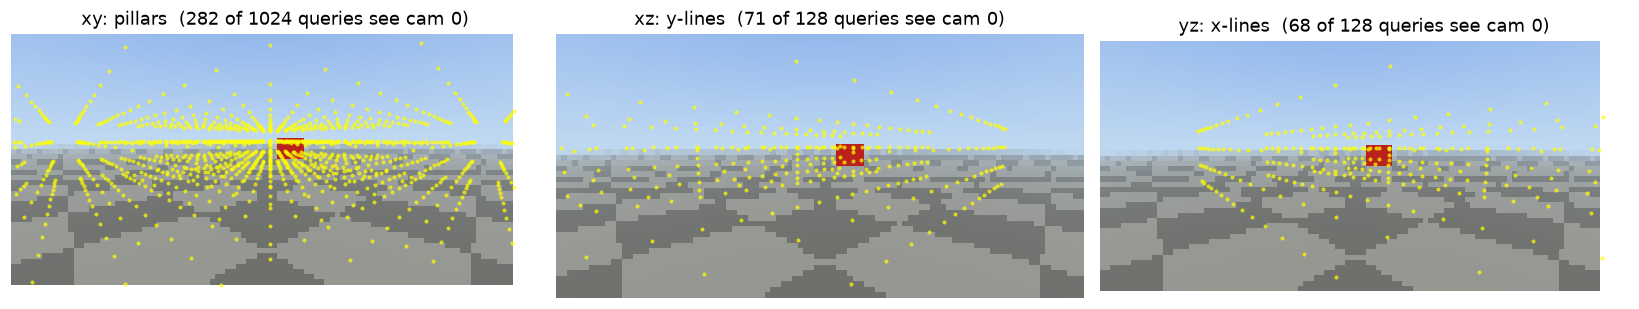

In [15]:
b, cam = 0, 0
H, W = batch.cameras.image_size
fig, ax = plt.subplots(1, 3, figsize=(15, 3.4))
for p, name in enumerate(["xy: pillars", "xz: y-lines", "yz: x-lines"]):
    uv, vis = cam_refs[p]
    pts = uv[b, cam][vis[b, cam]] * torch.tensor([W, H])           # back to pixels
    ax[p].imshow(batch.images[b, cam].permute(1, 2, 0))
    ax[p].scatter(pts[:, 0], pts[:, 1], s=3, c="yellow", alpha=0.6)
    ax[p].set_title(f"{name}  ({vis[b, cam].any(-1).sum().item()} of {vis.shape[2]} queries see cam {cam})")
    ax[p].axis("off")
plt.tight_layout(); plt.show()

**Takeaway:** the references are *pure geometry*, with no learning. They give each query a good starting guess on the image.
Next we let the network *refine* that guess.

## Step 7: Deformable attention, "look near here, and learn where"

Plain attention compares a query with **every** pixel: far too costly (thousands of tokens × thousands of pixels).
**Deformable attention** (Zhu et al. 2021) instead:

1. takes a *reference point* (from step 6),
2. predicts a few **learned offsets** from the query → `P` sampling locations around it,
3. reads image features there by **bilinear interpolation**,
4. mixes them with **learned weights** (softmax).

So each query reads only `P` pixels instead of all of them. The original needs a custom CUDA kernel;
here it's built from `F.grid_sample`. Let's demystify `multi_scale_deformable_attn_2d` on a toy and check against a hand-written loop.

In [16]:
# one image-feature level 6x8, 1 head, 2 channels
H_, W_ = 6, 8
value = torch.randn(1, H_ * W_, 1, 2)                       # (B, S, heads, dim)
loc = torch.tensor([[[[[[0.30, 0.40], [0.55, 0.60], [0.80, 0.20]]]]]])  # (B,Q,M,L,P=3,2) (x,y) in [0,1]
wts = torch.tensor([[[[[0.5, 0.3, 0.2]]]]])                 # (B,Q,M,L,P) sums to 1

out = multi_scale_deformable_attn_2d(value, [(H_, W_)], loc, wts)
print("op output:", out.shape, out.flatten().tolist())

def bilinear(img, x, y):                                    # img (H, W, D); x,y in [0,1]
    px, py = x * W_ - 0.5, y * H_ - 0.5                     # pixel i has its centre at i+0.5
    x0, y0 = math.floor(px), math.floor(py)
    res = torch.zeros(img.shape[-1])
    for dy in (0, 1):
        for dx in (0, 1):
            xi, yi = x0 + dx, y0 + dy
            w = (1 - abs(px - xi)) * (1 - abs(py - yi))
            if 0 <= xi < W_ and 0 <= yi < H_:               # outside the image reads zeros
                res += w * img[yi, xi]
    return res

img = value[0, :, 0].view(H_, W_, 2)
manual = sum(wts[0, 0, 0, 0, p] * bilinear(img, *loc[0, 0, 0, 0, p].tolist()) for p in range(3))
print("by hand  :", manual.tolist())
assert torch.allclose(out.flatten(), manual, atol=1e-5)
print("✓ matches the manual bilinear loop")

op output: torch.Size([1, 1, 2]) [-0.7009650468826294, 0.7519668340682983]
by hand  : [-0.7009650468826294, 0.7519667148590088]
✓ matches the manual bilinear loop


### The module that wraps it: `PillarDeformableAttention`
Inside TPVFormer, the **image cross-attention** uses `SpatialCrossAttention` → `PillarDeformableAttention`:

* The query is a plane cell; it has `A` projected anchors (from step 6).
* For **each anchor** it predicts `P/A` offsets → total `P` sampling points around the pillar/line.
* A softmax over all points gives the weights.
* Cameras that can't see the query are masked out; the rest are averaged.

At *initialisation* all offsets are fixed spokes around the anchors (heads fan out in different directions),
so even an untrained layer already "looks around" the geometry-derived location.

In [17]:
sca = SpatialCrossAttention(embed_dims=32, num_heads=4, num_levels=1, num_points=8, num_anchors=4)
n_params = sum(p.numel() for p in sca.parameters())
print("params:", n_params)

B, N, Q, A = 2, 4, 50, 4
q = torch.randn(B, Q, 32)
image_vals = torch.randn(B, N, 6 * 8, 32)             # (B, N cameras, S pixels, C)
ref = torch.rand(B, N, Q, A, 2)                       # normalised projected anchors
vis = torch.rand(B, N, Q, A) > 0.3                    # which anchors are visible
out = sca(q, image_vals, [(6, 8)], ref, vis)
print("in :", tuple(q.shape), " out:", tuple(out.shape), "(one updated vector per query)")

params: 5280


in : (2, 50, 32)  out: (2, 50, 32) (one updated vector per query)


## Step 8: Cross-view hybrid attention. Planes talk to each other

Each plane only sees its own projection. But a car looks like a car in *all* three planes, so they should share info.
**Cross-view hybrid attention** is deformable *self*-attention where the three planes are treated as **three levels** of one feature pyramid.
Every query (from any plane) samples points on **all three** planes.

The reference point must be *the same 3D location* expressed in each plane's coordinates. A query on `xy` knows `x, y` but not `z`;
the code fills the missing axis with the middle of its range. Let's look:

In [18]:
hyb = refs.hybrid_reference_points()
print("hybrid reference:", tuple(hyb.shape), "= (queries, 3 planes, (col,row))")

# An xy query at cell (x-index 20, y-index 16)
idx = 20 * 32 + 16
print("\nxy query (x=20/32, y=16/32), z unknown -> centre 0.5. Same 3D spot on each plane:")
for name, pt in zip(["xy (col=y,row=x)", "xz (col=z,row=x)", "yz (col=z,row=y)"], hyb[idx]):
    print(f"  on {name}: col={pt[0]:.3f} row={pt[1]:.3f}")

hybrid reference: (1280, 3, 2) = (queries, 3 planes, (col,row))

xy query (x=20/32, y=16/32), z unknown -> centre 0.5. Same 3D spot on each plane:
  on xy (col=y,row=x): col=0.516 row=0.641
  on xz (col=z,row=x): col=0.500 row=0.641
  on yz (col=z,row=y): col=0.500 row=0.516


In [19]:
cva = CrossViewHybridAttention(embed_dims=32, num_heads=4, num_points=4)
shapes = refs.plane_shapes
Qtot = sum(h * w for h, w in shapes)
query = torch.randn(2, Qtot, 32); pos = torch.randn(2, Qtot, 32)
out = cva(query, pos, shapes, hyb[None].expand(2, -1, -1, -1))
print(f"tokens in={tuple(query.shape)}  out={tuple(out.shape)}   (Qtot = {Qtot} = 1024 + 128 + 128)")

tokens in=(2, 1280, 32)  out=(2, 1280, 32)   (Qtot = 1280 = 1024 + 128 + 128)


## Step 9: One TPVFormer layer

A layer is a classic transformer block with the 3D-aware attentions:

```
tokens ──► cross-view hybrid attention ──► +residual, LayerNorm
       ──► image cross-attention (one per plane) ──► +residual, LayerNorm
       ──► feed-forward network ──► +residual, LayerNorm
```
*Hybrid attention* mixes the three planes. *Image cross-attention* pulls in **evidence from the pixels**. *FFN* adds capacity.
Note each plane has its own cross-attention (own offsets and number of anchors), splitting the tokens by plane.

### 🖼️ Diagram: where this layer sits in the whole model

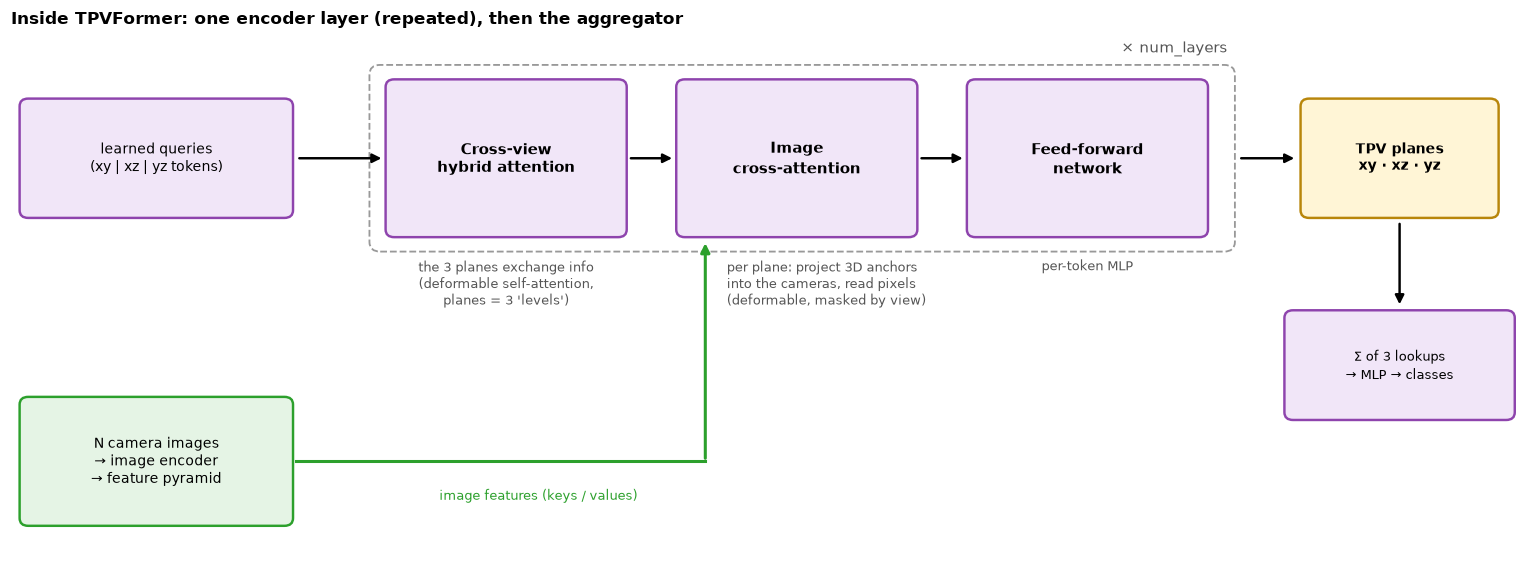

In [20]:
dg.fig_tpv_layer()

In [21]:
layer = TPVFormerLayer(embed_dims=32, num_heads=4, num_levels=1, num_anchors=(4, 8, 8))
B, N = 2, 4
query = torch.randn(B, Qtot, 32); pos = torch.randn(B, Qtot, 32)
img = torch.randn(B, N, 6 * 8, 32)
cam_refs_toy = [(torch.rand(B, N, h * w, a, 2), torch.rand(B, N, h * w, a) > 0.3)
                for (h, w), a in zip(shapes, (4, 8, 8))]
out = layer(query, pos, shapes, hyb[None].expand(B, -1, -1, -1), img, [(6, 8)], cam_refs_toy)
print("layer in:", tuple(query.shape), "-> out:", tuple(out.shape), " (shape preserved, so layers stack)")

layer in: (2, 1280, 32) -> out: (2, 1280, 32)  (shape preserved, so layers stack)


## Step 10: The whole lifter, images → TPV planes

`TPVFormerLifter.lift_planes(features, cameras)`:

1. **Flatten** the image feature pyramid into tokens (`flatten_pyramid`) and add a learned *level embedding*.
2. Compute the **reference points** (steps 6 and 8) from the calibration.
3. Start from **learned queries** (`nn.Parameter`, one vector per plane cell), with learned positional embeddings.
4. Run `num_layers` layers (step 9).
5. Reshape tokens back to `TPVPlanes`.

Let's pull it apart with a real image encoder.

In [22]:
from lifting.encoders import SimpleConvEncoder
encoder = SimpleConvEncoder(out_channels=32, num_levels=2)
b, n = batch.images.shape[:2]
with torch.no_grad():
    feats = [f.view(b, n, *f.shape[1:]) for f in encoder(batch.images.flatten(0, 1))]
print("image features (B, N, C, H_l, W_l) per level:")
for i, f in enumerate(feats):
    print(f"  level {i}: {tuple(f.shape)}")

lifter = TPVFormerLifter(grid, in_channels=32, out_channels=32, num_layers=2)
print("\nlearned query tokens:", tuple(lifter.queries.shape), "= (1024+128+128, C)")
print("lifter params       :", f"{sum(p.numel() for p in lifter.parameters()):,}")

with torch.no_grad():
    planes = lifter.lift_planes(feats, batch.cameras)
print("\nplanes -> xy", tuple(planes.xy.shape), " xz", tuple(planes.xz.shape), " yz", tuple(planes.yz.shape))

image features (B, N, C, H_l, W_l) per level:
  level 0: (4, 4, 32, 12, 24)
  level 1: (4, 4, 32, 6, 12)

learned query tokens: (1280, 32) = (1024+128+128, C)
lifter params       : 186,784

planes -> xy (4, 32, 32, 32)  xz (4, 32, 32, 4)  yz (4, 32, 32, 4)


Note the lifter is also a normal BEV lifter: `forward()` sums the planes into voxels and compresses the height with `HeightCompressor` so TPVFormer can be compared against BEVFormer, Lift-Splat etc. in the same benchmark.

In [23]:
with torch.no_grad():
    bev = lifter(feats, batch.cameras)
print("lifter(...) as a BEV lifter:", tuple(bev.shape), "= (B, C, X, Y)")

lifter(...) as a BEV lifter: (4, 32, 32, 32) = (B, C, X, Y)


## Step 11: Planes → semantics: the `TPVAggregator`

The planes hold features. To get **classes** (empty / vehicle / pedestrian) we:

1. build the voxel volume `f = xy + xz + yz` (step 3),
2. run a tiny **MLP** (`Linear → Softplus → Linear`) and a `Linear` classifier **per voxel**.

Because planes can be sampled anywhere (`sample_points`), the same MLP can classify **arbitrary 3D points**, e.g. a LiDAR sweep.
No voxelisation needed. This is TPV's neat trick.

In [24]:
agg = TPVAggregator(grid, in_channels=32, num_classes=3)
pts = torch.rand(4, 500, 3) * torch.tensor([32.0, 32.0, 4.0]) + torch.tensor([-16.0, -16.0, -1.0])  # random LiDAR-ish points
with torch.no_grad():
    out = agg(planes, points=pts)
print("voxel_logits:", tuple(out["voxel_logits"].shape), "= (B, classes, X, Y, Z)")
print("point_logits:", tuple(out["point_logits"].shape), "= (B, classes, P)")

voxel_logits: (4, 3, 32, 32, 4) = (B, classes, X, Y, Z)
point_logits: (4, 3, 500) = (B, classes, P)


And the full model is just three blocks glued together: `build_tpvformer` = **encoder → lifter → aggregator**.

In [25]:
model = build_tpvformer(grid, num_classes=3, channels=32)
with torch.no_grad():
    out = model(batch.images, batch.cameras, points=pts)
print({k: (tuple(v.shape) if torch.is_tensor(v) else type(v).__name__) for k, v in out.items()})
print(f"\ntotal parameters: {sum(p.numel() for p in model.parameters()):,}")
for name, mod in model.named_children():
    print(f"  {name:11s} {sum(p.numel() for p in mod.parameters()):>9,}")

{'planes': 'TPVPlanes', 'voxel_logits': (4, 3, 32, 32, 4), 'point_logits': (4, 3, 500)}

total parameters: 309,571
  encoder       118,496
  lifter        186,784
  aggregator      4,291


## Step 12: Train it and watch it learn

Loss: weighted cross-entropy over all `X·Y·Z` voxels (classes `vehicle` and `pedestrian` weighted ×8 since most voxels are empty).
Metric: **mIoU over the foreground classes**: intersection-over-union of vehicle and pedestrian, averaged.

We train on 192 scenes and test on 64 **unseen** scenes. About a minute on CPU.

In [26]:
torch.manual_seed(0)
def make_batches(lo, hi, bs=4):
    return [SceneBatch.collate([data[i + j] for j in range(bs)]) for i in range(lo, hi, bs)]

train_batches = make_batches(0, 192)
test_batches  = make_batches(192, 256)

model = build_tpvformer(grid, num_classes=3, channels=32)
trainer = Trainer(model, OccupancyTask(num_classes=3))
print("mIoU before training:", round(trainer.evaluate(test_batches).mean_foreground(), 3))

t0 = time.time()
trainer.fit(train_batches, steps=250)
print(f"trained 250 steps in {time.time() - t0:.0f}s")
print("mIoU after training :", round(trainer.evaluate(test_batches).mean_foreground(), 3))

mIoU before training: 0.01


In [ ]:
losses = trainer.history.losses
plt.figure(figsize=(6, 3))
plt.plot(losses, alpha=0.3, label="per step"); plt.plot(trainer.history.smoothed(15), label="smoothed")
plt.xlabel("step"); plt.ylabel("loss"); plt.legend(); plt.title("TPVFormer occupancy training"); plt.tight_layout(); plt.show()

### What did it predict? Ground truth vs prediction on **unseen** scenes
Top row: ground-truth occupancy (collapsed over height). Bottom: prediction.
Below, a "side view" collapses over `y` instead, showing the height information the TPV keeps.

In [ ]:
tb = test_batches[0]
pred = trainer.predict(tb)                      # (B, X, Y, Z)
ext = [grid.x_bounds[0], grid.x_bounds[1], grid.y_bounds[0], grid.y_bounds[1]]

fig, ax = plt.subplots(4, 4, figsize=(11, 10))
for s in range(4):
    ax[0, s].imshow(tb.occupancy[s].amax(2).T, origin="lower", vmin=0, vmax=2, extent=ext); ax[0, s].set_title(f"scene {s} GT (top)")
    ax[1, s].imshow(pred[s].amax(2).T,          origin="lower", vmin=0, vmax=2, extent=ext); ax[1, s].set_title("prediction (top)")
    ax[2, s].imshow(tb.occupancy[s].amax(1).T, origin="lower", vmin=0, vmax=2, aspect="auto"); ax[2, s].set_title("GT side (x vs z)")
    ax[3, s].imshow(pred[s].amax(1).T,          origin="lower", vmin=0, vmax=2, aspect="auto"); ax[3, s].set_title("pred side (x vs z)")
for a in ax.ravel(): a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

### Peek inside: what do the learned planes look like?
We show the *feature magnitude* (L2 norm over channels) of each plane. Cells where objects sit usually light up.

In [ ]:
model.eval()
with torch.no_grad():
    o = model(tb.images, tb.cameras)
pl = o["planes"]
fig, ax = plt.subplots(1, 4, figsize=(14, 3.2))
for a, (name, p) in zip(ax[:3], [("xy (top)", pl.xy), ("xz (side)", pl.xz), ("yz (front)", pl.yz)]):
    im = a.imshow(p[0].norm(dim=0), cmap="magma", aspect="auto"); a.set_title(f"plane {name}\n|feature|"); plt.colorbar(im, ax=a, fraction=0.046)
ax[3].imshow(tb.occupancy[0].amax(2), cmap="viridis", vmin=0, vmax=2); ax[3].set_title("GT top view\n(same orientation as xy)")
plt.tight_layout(); plt.show()

### Bonus: query arbitrary 3D points
We classify random points and compare with the ground truth at the voxel the point falls into.
Because points between voxel centres are bilinearly interpolated, they're not tied to the grid.

In [ ]:
pts = torch.rand(4, 2000, 3) * torch.tensor([32.0, 32.0, 4.0]) + torch.tensor([-16.0, -16.0, -1.0])
with torch.no_grad():
    o = model(tb.images, tb.cameras, points=pts)
pred_pts = o["point_logits"].argmax(1)                              # (B, P)
idx = grid.to_index(pts).floor().long().clamp(min=0)
idx[..., 0].clamp_(max=31); idx[..., 1].clamp_(max=31); idx[..., 2].clamp_(max=3)
gt_pts = torch.stack([tb.occupancy[b][idx[b, :, 0], idx[b, :, 1], idx[b, :, 2]] for b in range(4)])
print("point accuracy (dominated by 'empty'):", (pred_pts == gt_pts).float().mean().item())
fg = gt_pts > 0
print(f"foreground points: {fg.sum().item()}  recall on them: {(pred_pts[fg] == gt_pts[fg]).float().mean().item():.2f}")

## Step 13: Prove it really uses geometry 🔬

Is the model "cheating" with some shortcut, or really using the camera poses? A great test:
**keep the images and labels unchanged but rotate the camera extrinsics by 90°.** If the network genuinely
maps pixels → 3D through the calibration, its predictions must now be wrong.

In [ ]:
import dataclasses
from lifting.geometry import Cameras

Rz = torch.eye(4)
Rz[0, 0], Rz[0, 1], Rz[1, 0], Rz[1, 1] = 0.0, -1.0, 1.0, 0.0       # 90 degrees about z

def rotate_rig(b):
    return dataclasses.replace(b, cameras=b.cameras.transformed(Rz))

good = trainer.evaluate(test_batches).mean_foreground()
bad  = trainer.evaluate(test_batches, transform=rotate_rig).mean_foreground()
print(f"mIoU with correct extrinsics : {good:.3f}")
print(f"mIoU with rotated extrinsics : {bad:.3f}")
print(f"-> drops by {100 * (1 - bad / max(good, 1e-9)):.0f}%")

The score collapses: the network reads pixels **through the geometry** (the reference points of step 6 come from the calibration).
This is precisely the check the repo's `lifting-verify` tool does for every lifter, versus a geometry-free `mlp_view` baseline.

## Step 14: Recap & exercises

**The whole pipeline in one picture**

```
 N camera images ──► image encoder ──► feature pyramid  ──────────────┐
                                                                      ▼
 learned plane queries (xy | xz | yz tokens) ──► [ cross-view hybrid attention  ← planes exchange info
        ▲                                        [ image cross-attention        ← reference points from
        │  repeat num_layers                     [ feed-forward                    projecting 3D anchors
        └─────────────────────────────────────────                                  with cameras ]
                          │
                          ▼
                 TPVPlanes (xy, xz, yz)
                          │   f(x,y,z) = xy + xz + yz
                          ▼
              TPVAggregator (MLP) ──► semantics for every voxel / any 3D point
```

**Cheat sheet**

| concept | file |
|---|---|
| metric grid | `src/lifting/geometry/grid.py` |
| camera projection | `src/lifting/geometry/cameras.py` |
| three planes + sum | `src/lifting/lifters/tpvformer/tpv_planes.py` |
| reference points | `src/lifting/lifters/tpvformer/tpv_reference_points.py` |
| deformable attention op | `src/lifting/ops/ms_deform_attn_2d.py` |
| image cross-attention | `src/lifting/attention/{spatial_cross,pillar_deformable}_attention.py` |
| hybrid attention | `src/lifting/attention/cross_view_hybrid_attention.py` |
| layer / lifter | `src/lifting/lifters/tpvformer/tpvformer_{layer,lifter}.py` |
| aggregator / full model | `tpv_aggregator.py`, `src/lifting/models/tpvformer.py` |

### 🧪 Exercises
1. **Change the plane anchors**: build the model with `num_anchors=(2, 4, 4)` and `(8, 16, 16)`. How do speed and mIoU change? (`build_tpvformer(..., num_anchors=(...))`; the cross-attention needs `points_per_anchor × anchors` points.)
2. **Depth of the stack**: try `num_layers=1` vs `4`.
3. **Aux heads**: use `build_tpvformer(grid, 3, channels=32, aux_heads=True)` with `OccupancyTask(3, aux_weight=0.5)`. Does supervising each plane help?
4. **Make it harder**: set `GridSpec(resolution=(32, 32, 8))`. Planes get taller; what happens to cost?
5. **Ablate hybrid attention**: in `TPVFormerLayer.forward` skip `hybrid_attn` (use `q = query`). Do the planes still learn?
6. **Compare lifters**: replace `build_tpvformer` with `build_bev_model("bevformer" | "lift_splat" | "simple_bev", grid, ...)` and train with `BEVSegmentationTask`. TPV's `xy` plane is a BEV map, so how close does it get?
7. **Visualise attention**: hook `PillarDeformableAttention.forward` to record the sampling `locations` for one query and plot them on a camera image.

Next reading: the TPVFormer paper (arXiv 2302.07817), then `README.md` → *Verification* to see how all lifters are compared.